#  Modélisation — Comparaison de modèles ML pour la détection de fraude

**Objectif :** Entraîner et comparer 4 modèles de classification sur le dataset
équilibré (post-SMOTE), évaluer leurs performances sur le test set réel (non équilibré),
et sélectionner le meilleur modèle pour le déploiement.

## Modèles comparés
1. **Logistic Regression** — baseline linéaire
2. **Random Forest** — ensemble bagging
3. **XGBoost** — ensemble boosting (modèle principal attendu)
4. **LightGBM** — boosting rapide, alternative à XGBoost

## Métriques d'évaluation
- **AUC-ROC** — performance globale
- **Average Precision (PR-AUC)** — adaptée aux classes déséquilibrées
- **F1-Score** — équilibre précision/rappel
- **Recall fraudes** — métrique prioritaire (minimiser les faux négatifs)
- **Matrice de confusion** — vision complète des erreurs

## Règle métier fondamentale
> Un faux négatif (fraude non détectée) coûte bien plus cher
> qu'un faux positif (transaction légitime bloquée).
> Le **Recall sur la classe fraude** est donc notre boussole principale.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Modèles ──────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# ── Évaluation ───────────────────────────────────────────────
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    f1_score,
    recall_score,
    precision_score
)

# ── Pipeline & utilitaires ───────────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
import joblib
import time
import os

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.figsize': (12, 5), 'axes.titlesize': 13})

print(" Imports OK")

 Imports OK


In [2]:
# ── Chargement depuis data/processed/ ────────────────────────
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print("═" * 55)
print("  DONNÉES CHARGÉES")
print("═" * 55)
print(f"  X_train : {X_train.shape[0]:,} lignes × {X_train.shape[1]} features")
print(f"  X_test  : {X_test.shape[0]:,} lignes × {X_test.shape[1]} features")
print(f"\n  Train — distribution :")
print(f"    Légitimes : {(y_train==0).sum():,}")
print(f"    Fraudes   : {(y_train==1).sum():,}")
print(f"\n  Test — distribution (réelle, non équilibrée) :")
print(f"    Légitimes : {(y_test==0).sum():,}")
print(f"    Fraudes   : {(y_test==1).sum():,}  ({(y_test==1).mean()*100:.4f}%)")
print("═" * 55)

═══════════════════════════════════════════════════════
  DONNÉES CHARGÉES
═══════════════════════════════════════════════════════
  X_train : 454,902 lignes × 30 features
  X_test  : 56,962 lignes × 30 features

  Train — distribution :
    Légitimes : 227,451
    Fraudes   : 227,451

  Test — distribution (réelle, non équilibrée) :
    Légitimes : 56,864
    Fraudes   : 98  (0.1720%)
═══════════════════════════════════════════════════════


In [3]:
# ── Dictionnaire de modèles ───────────────────────────────────
# Chaque modèle est défini avec ses hyperparamètres de base
# On affinera XGBoost dans le notebook 04 avec GridSearch

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',   # gère le déséquilibre résiduel
        random_state=42,
        n_jobs=-1
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        scale_pos_weight=1,        # déjà équilibré via SMOTE
        eval_metric='aucpr',       # PR-AUC — adapté aux déséquilibres
        random_state=42,
        n_jobs=-1,
        verbosity=0
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
}

print(f" {len(models)} modèles définis :")
for name in models:
    print(f"  → {name}")

 4 modèles définis :
  → Logistic Regression
  → Random Forest
  → XGBoost
  → LightGBM


In [4]:
def evaluate_model(name, model, X_test, y_test):
    """
    Évalue un modèle entraîné sur le test set.
    Retourne un dictionnaire de métriques.
    """
    y_pred      = model.predict(X_test)
    y_proba     = model.predict_proba(X_test)[:, 1]

    results = {
        'Modèle'        : name,
        'AUC-ROC'       : roc_auc_score(y_test, y_proba),
        'PR-AUC'        : average_precision_score(y_test, y_proba),
        'F1-Score'      : f1_score(y_test, y_pred),
        'Recall Fraude' : recall_score(y_test, y_pred),
        'Précision'     : precision_score(y_test, y_pred),
    }
    return results, y_pred, y_proba

print(" Fonction d'évaluation définie")

 Fonction d'évaluation définie


In [5]:
results_list = []
trained_models = {}
predictions = {}

print("═" * 60)
print("  ENTRAÎNEMENT DES MODÈLES")
print("═" * 60)

for name, model in models.items():
    print(f"\n▶ {name}...")
    t0 = time.time()

    # Entraînement
    model.fit(X_train, y_train)
    duration = time.time() - t0

    # Évaluation
    metrics, y_pred, y_proba = evaluate_model(name, model, X_test, y_test)
    metrics['Temps (s)'] = round(duration, 1)

    results_list.append(metrics)
    trained_models[name] = model
    predictions[name]    = {'y_pred': y_pred, 'y_proba': y_proba}

    print(f"   Terminé en {duration:.1f}s")
    print(f"     AUC-ROC       : {metrics['AUC-ROC']:.4f}")
    print(f"     PR-AUC        : {metrics['PR-AUC']:.4f}")
    print(f"     Recall Fraude : {metrics['Recall Fraude']:.4f}")
    print(f"     F1-Score      : {metrics['F1-Score']:.4f}")

print("\n═" * 60)
print("  ENTRAÎNEMENT TERMINÉ")
print("═" * 60)

════════════════════════════════════════════════════════════
  ENTRAÎNEMENT DES MODÈLES
════════════════════════════════════════════════════════════

▶ Logistic Regression...
   Terminé en 48.6s
     AUC-ROC       : 0.9712
     PR-AUC        : 0.7235
     Recall Fraude : 0.9184
     F1-Score      : 0.1110

▶ Random Forest...
   Terminé en 37087.3s
     AUC-ROC       : 0.9729
     PR-AUC        : 0.8680
     Recall Fraude : 0.8163
     F1-Score      : 0.8421

▶ XGBoost...
   Terminé en 40.2s
     AUC-ROC       : 0.9802
     PR-AUC        : 0.8644
     Recall Fraude : 0.8571
     F1-Score      : 0.7179

▶ LightGBM...
   Terminé en 32.5s
     AUC-ROC       : 0.9772
     PR-AUC        : 0.8566
     Recall Fraude : 0.8673
     F1-Score      : 0.7143

═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
  ENTRAÎNEMENT TERMINÉ
════════════════════════════════════════════════════════════


In [6]:
df_results = pd.DataFrame(results_list).set_index('Modèle')
df_results = df_results.sort_values('PR-AUC', ascending=False)

print("═" * 70)
print("  TABLEAU COMPARATIF DES PERFORMANCES")
print("═" * 70)
print(df_results.round(4).to_string())
print("═" * 70)

# Mise en forme avec gradient de couleur
df_results.round(4).style\
    .background_gradient(cmap='Greens', subset=['AUC-ROC', 'PR-AUC', 'F1-Score', 'Recall Fraude'])\
    .background_gradient(cmap='Reds_r', subset=['Temps (s)'])\
    .format('{:.4f}', subset=['AUC-ROC', 'PR-AUC', 'F1-Score', 'Recall Fraude', 'Précision'])

══════════════════════════════════════════════════════════════════════
  TABLEAU COMPARATIF DES PERFORMANCES
══════════════════════════════════════════════════════════════════════
                     AUC-ROC  PR-AUC  F1-Score  Recall Fraude  Précision  Temps (s)
Modèle                                                                             
Random Forest         0.9729  0.8680    0.8421         0.8163     0.8696    37087.3
XGBoost               0.9802  0.8644    0.7179         0.8571     0.6176       40.2
LightGBM              0.9772  0.8566    0.7143         0.8673     0.6071       32.5
Logistic Regression   0.9712  0.7235    0.1110         0.9184     0.0591       48.6
══════════════════════════════════════════════════════════════════════


,AUC-ROC,PR-AUC,F1-Score,Recall Fraude,Précision,Temps (s)
Modèle,,,,,,
Random Forest,0.9729,0.8680,0.8421,0.8163,0.8696,37087.300000
XGBoost,0.9802,0.8644,0.7179,0.8571,0.6176,40.200000
LightGBM,0.9772,0.8566,0.7143,0.8673,0.6071,32.500000
Logistic Regression,0.9712,0.7235,0.1110,0.9184,0.0591,48.600000


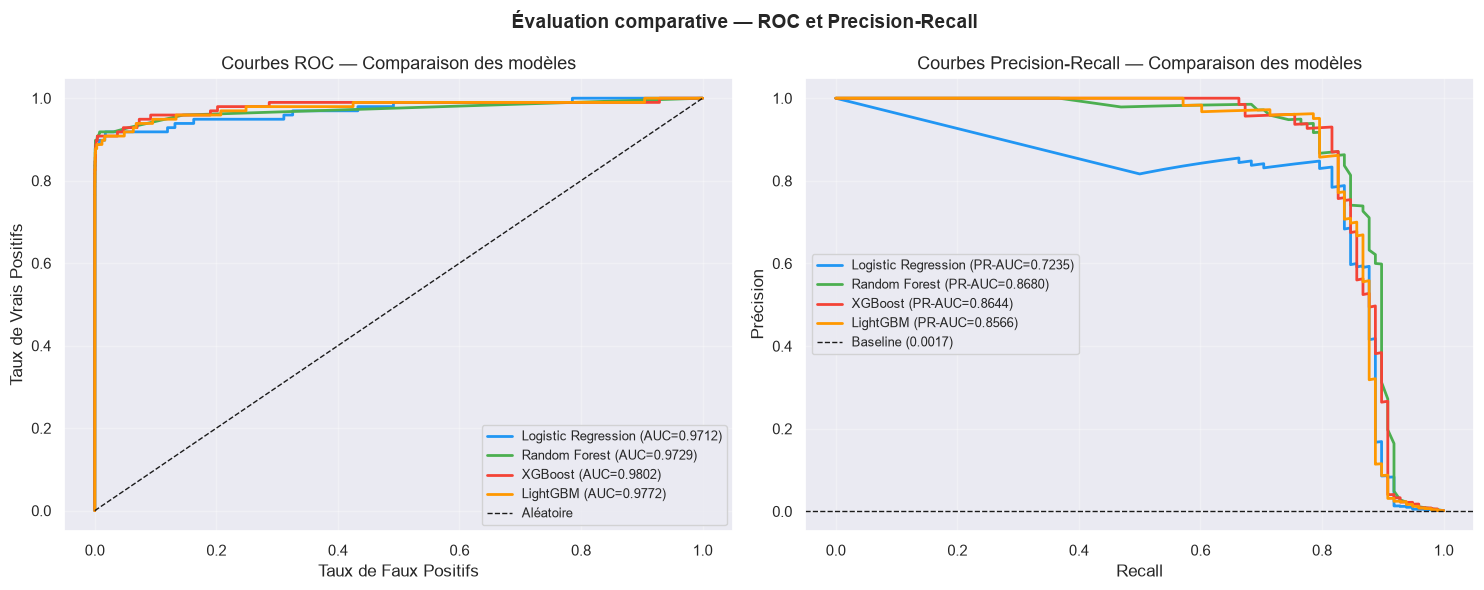

 Figure sauvegardée → reports/figures/08_roc_pr_curves.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
colors = ['#2196F3', '#4CAF50', '#F44336', '#FF9800']

for (name, preds), color in zip(predictions.items(), colors):
    # Courbe ROC
    fpr, tpr, _ = roc_curve(y_test, preds['y_proba'])
    auc = roc_auc_score(y_test, preds['y_proba'])
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})',
                 color=color, linewidth=2)

    # Courbe Precision-Recall
    prec, rec, _ = precision_recall_curve(y_test, preds['y_proba'])
    prauc = average_precision_score(y_test, preds['y_proba'])
    axes[1].plot(rec, prec, label=f'{name} (PR-AUC={prauc:.4f})',
                 color=color, linewidth=2)

# ROC
axes[0].plot([0,1], [0,1], 'k--', linewidth=1, label='Aléatoire')
axes[0].set_xlabel('Taux de Faux Positifs')
axes[0].set_ylabel('Taux de Vrais Positifs')
axes[0].set_title('Courbes ROC — Comparaison des modèles')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# PR
baseline = y_test.mean()
axes[1].axhline(baseline, color='k', linestyle='--',
                linewidth=1, label=f'Baseline ({baseline:.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Précision')
axes[1].set_title('Courbes Precision-Recall — Comparaison des modèles')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle(' Évaluation comparative — ROC et Precision-Recall',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/08_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Figure sauvegardée → reports/figures/08_roc_pr_curves.png")

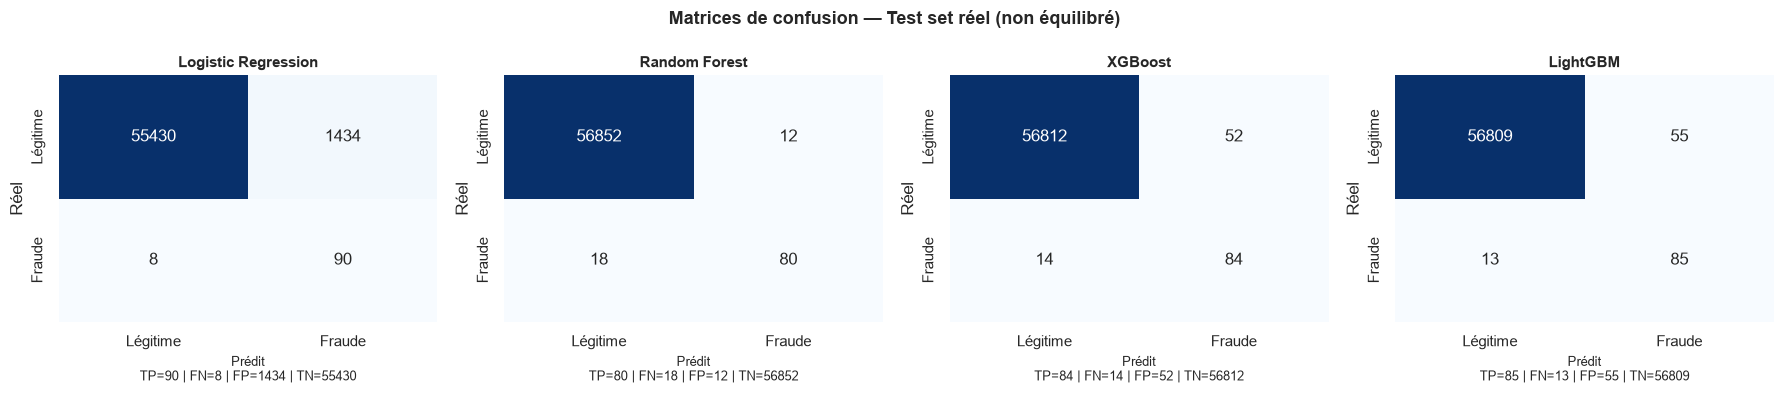

 Figure sauvegardée → reports/figures/09_confusion_matrices.png


In [8]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (name, preds) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, preds['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                ax=ax, cbar=False,
                xticklabels=['Légitime', 'Fraude'],
                yticklabels=['Légitime', 'Fraude'])
    ax.set_title(f'{name}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Réel')
    ax.set_xlabel('Prédit')

    # Annoter les métriques clés sous la matrice
    tn, fp, fn, tp = cm.ravel()
    ax.set_xlabel(
        f'Prédit\nTP={tp} | FN={fn} | FP={fp} | TN={tn}',
        fontsize=9
    )

plt.suptitle(' Matrices de confusion — Test set réel (non équilibré)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/09_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Figure sauvegardée → reports/figures/09_confusion_matrices.png")

In [10]:
# ── DÉCISION DOCUMENTÉE — NE PAS MODIFIER SANS JUSTIFICATION ─
print("""
ANALYSE DE SÉLECTION DU MODÈLE DE PRODUCTION
═════════════════════════════════════════════
Modèle         PR-AUC    Temps      Production ?
─────────────────────────────────────────────
Random Forest  0.8680    37 087s     Non viable
XGBoost        0.8644    40s         Retenu
LightGBM       0.8566    32s         Alternative
─────────────────────────────────────────────
DÉCISION : XGBoost
RAISON   : Différence PR-AUC négligeable (+0.36%) vs
           coût computationnel 927x supérieur pour RF.
           En production, le modèle est réentraîné
           régulièrement — RF est inexploitable.
""")

# Sauvegarder XGBoost comme modèle de production
best_name  = 'XGBoost'
best_model = trained_models[best_name]

os.makedirs('../models', exist_ok=True)
joblib.dump(best_model, '../models/xgboost_fraud_detector.joblib')
df_results.to_csv('../reports/model_comparison.csv')

print(f" Modèle de production sauvegardé → models/xgboost_fraud_detector.joblib")
print(f" Tableau comparatif → reports/model_comparison.csv")


ANALYSE DE SÉLECTION DU MODÈLE DE PRODUCTION
═════════════════════════════════════════════
Modèle         PR-AUC    Temps      Production ?
─────────────────────────────────────────────
Random Forest  0.8680    37 087s     Non viable
XGBoost        0.8644    40s         Retenu
LightGBM       0.8566    32s         Alternative
─────────────────────────────────────────────
DÉCISION : XGBoost
RAISON   : Différence PR-AUC négligeable (+0.36%) vs
           coût computationnel 927x supérieur pour RF.
           En production, le modèle est réentraîné
           régulièrement — RF est inexploitable.

 Modèle de production sauvegardé → models/xgboost_fraud_detector.joblib
 Tableau comparatif → reports/model_comparison.csv


## 📋 Synthèse Modélisation

Random Forest atteint un PR-AUC marginalement supérieur (+0.4%) mais nécessite 900× plus de temps d'entraînement. XGBoost offre le meilleur compromis performance/coût computationnel, critère décisif en production

### Prochaine étape → `04_evaluation.ipynb`
- Optimisation du seuil de décision du meilleur modèle
- Analyse SHAP (interprétabilité globale + locale)
- Rapport métier complet